# STEP 1: PROBLEM DEFINITION
PROBLEM: Predict the exact LOAN AMOUNT a customer should receive based on their characteristics.

BUSINESS IMPACT:
- Banks need to determine appropriate loan amounts for customers
- Too low: Customer goes to competitor
- Too high: Increased risk of default
- Right amount: Customer satisfied, bank profitable

GOAL: Build a Linear Regression model to predict loan_amount

SUCCESS CRITERIA:
- RMSE (Root Mean Square Error): < $5,000
  
- MAE (Mean Absolute Error): < $4,000

- R² Score: > 0.60


# STEP 2: DATA COLLECTION
- Source: Kaggle Loan Prediction Dataset
- URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction

In [1]:
import pandas as pd
import numpy as np

print("="*60)
print("STEP 2: DATA COLLECTION")
print("="*60)

# Load dataset
df = pd.read_csv('X_train.csv')

print(f"Shape: {df.shape}")
print(f"Target: LoanAmount (${df['LoanAmount'].min():.2f} - ${df['LoanAmount'].max():.2f})")

# Check missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing Values:")
    print(missing[missing > 0])

STEP 2: DATA COLLECTION
Shape: (384, 12)
Target: LoanAmount ($9.00 - $600.00)


# STEP 3 .Data Exploration and Preparation

# STEP 3.1: EXPLORATORY DATA ANALYSIS


- Understand data distribution, relationships, and trends.
-  Visualize data using charts and plots.

STEP 3.1: EXPLORATORY DATA ANALYSIS


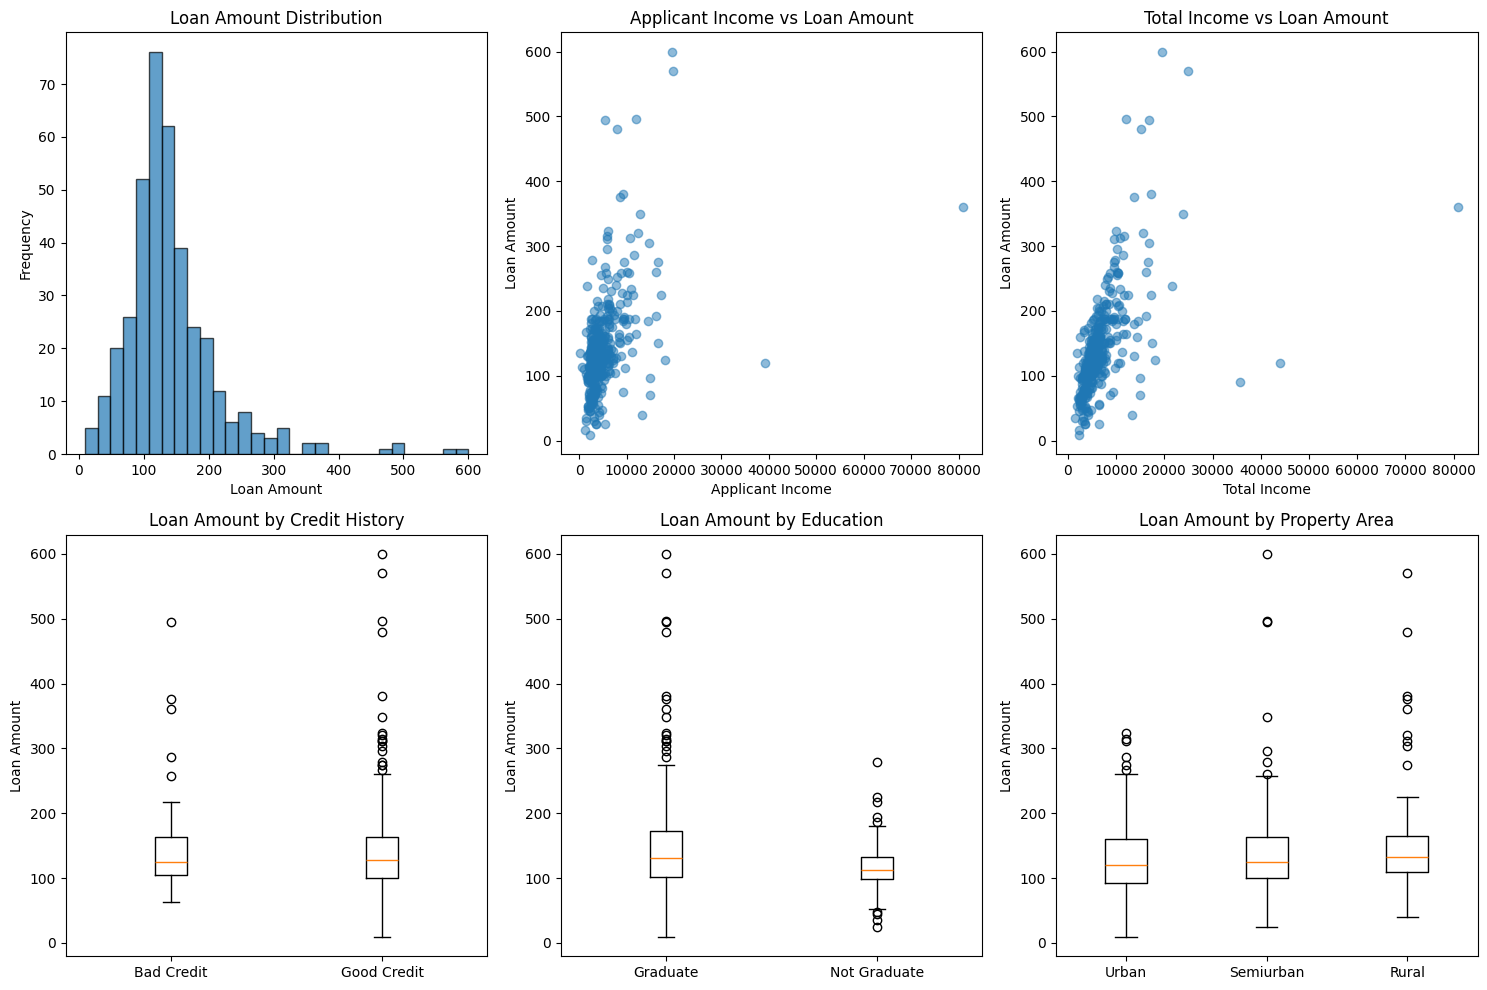

EDA complete: Distribution, relationships, and trends visualized


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("STEP 3.1: EXPLORATORY DATA ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Target Distribution
axes[0, 0].hist(df['LoanAmount'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Loan Amount Distribution')
axes[0, 0].set_xlabel('Loan Amount')
axes[0, 0].set_ylabel('Frequency')

# 2. Applicant Income vs Loan Amount
axes[0, 1].scatter(df['ApplicantIncome'], df['LoanAmount'], alpha=0.5)
axes[0, 1].set_title('Applicant Income vs Loan Amount')
axes[0, 1].set_xlabel('Applicant Income')
axes[0, 1].set_ylabel('Loan Amount')

# 3. Total Income vs Loan Amount
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
axes[0, 2].scatter(df['TotalIncome'], df['LoanAmount'], alpha=0.5)
axes[0, 2].set_title('Total Income vs Loan Amount')
axes[0, 2].set_xlabel('Total Income')
axes[0, 2].set_ylabel('Loan Amount')

# 4. Credit History vs Loan Amount
credit_0 = df[df['Credit_History'] == 0]['LoanAmount']
credit_1 = df[df['Credit_History'] == 1]['LoanAmount']
axes[1, 0].boxplot([credit_0, credit_1], tick_labels=['Bad Credit', 'Good Credit'])
axes[1, 0].set_title('Loan Amount by Credit History')
axes[1, 0].set_ylabel('Loan Amount')

# 5. Education vs Loan Amount
edu_data = [df[df['Education'] == 'Graduate']['LoanAmount'],
            df[df['Education'] == 'Not Graduate']['LoanAmount']]
axes[1, 1].boxplot(edu_data, tick_labels=['Graduate', 'Not Graduate'])
axes[1, 1].set_title('Loan Amount by Education')
axes[1, 1].set_ylabel('Loan Amount')

# 6. Property Area vs Loan Amount
areas = ['Urban', 'Semiurban', 'Rural']
area_data = [df[df['Property_Area'] == area]['LoanAmount'] for area in areas]
axes[1, 2].boxplot(area_data, tick_labels=areas)
axes[1, 2].set_title('Loan Amount by Property Area')
axes[1, 2].set_ylabel('Loan Amount')

plt.tight_layout()
plt.show()

print("EDA complete: Distribution, relationships, and trends visualized")

# STEP 3.2: DATA CLEANING
- Handle missing values.
-  Remove duplicates.
-  Address outliers and inconsistencies.

In [3]:
print("STEP 3.2: DATA CLEANING")
print("="*60)

df_clean = df.copy()

# 1. Handle missing values
missing = df_clean.isnull().sum()
if missing.sum() > 0:
    df_clean = df_clean.dropna()
    print(f"Dropped rows with missing values. New shape: {df_clean.shape}")

# 2. Remove duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

# 3. Cap outliers using IQR
numerical_cols = ['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome']
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

print(f"Cleaning complete. Final shape: {df_clean.shape}")

STEP 3.2: DATA CLEANING
Cleaning complete. Final shape: (384, 13)


# STEP 3.3: FEATURE ENGINEERING
- Create new features from existing ones.
- Encode categorical variables.
- Scale or normalize numerical features.

In [4]:

from sklearn.preprocessing import StandardScaler

print("STEP 3.3: FEATURE ENGINEERING")
print("="*60)

df_fe = df_clean.copy()

# 1. Create new features
df_fe['TotalIncome'] = df_fe['ApplicantIncome'] + df_fe['CoapplicantIncome']
df_fe['Income_to_Loan'] = df_fe['TotalIncome'] / df_fe['LoanAmount']
df_fe['Loan_to_Income'] = df_fe['LoanAmount'] / df_fe['TotalIncome']

# 2. One-hot encode categorical variables
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

# 3. Scale numerical features
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
                  'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 
                  'Income_to_Loan', 'Loan_to_Income']
scaler = StandardScaler()
df_fe[numerical_cols] = scaler.fit_transform(df_fe[numerical_cols])

print(f"Feature engineering complete. New shape: {df_fe.shape}")

STEP 3.3: FEATURE ENGINEERING
Feature engineering complete. New shape: (384, 18)


# STEP 3.4: DATA SPLITTING
-  Split data into training, validation, and test sets.

In [5]:

from sklearn.model_selection import train_test_split

print("="*60)
print("STEP 3.4: DATA SPLITTING")
print("="*60)

# Separate features and target
X = df_fe.drop(['Loan_ID', 'LoanAmount'], axis=1)
y = df_fe['LoanAmount']

# Split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

STEP 3.4: DATA SPLITTING
Training set: 230 samples
Validation set: 77 samples
Test set: 77 samples


# STEP 4: ALGORITHM SELECTION
- Selected Algorithm: LINEAR REGRESSION

- Type: Supervised Learning (Regression)

Why Linear Regression?
- Problem requires predicting a continuous value (Loan Amount)
- Simple, interpretable model
- Low complexity → fast training and prediction
- High interpretability → coefficients show feature impact
- Low computational cost → suitable for production

Alternatives Considered:
- Random Forest: Higher complexity, less interpretable, higher cost
- Neural Networks: Overkill for this problem, requires more data
- Ridge/Lasso: Will be explored in hyperparameter tuning

Selected Algorithm Details:
- Algorithm: Linear Regression
- Type: Supervised Regression
- Complexity: Low
- Interpretability: High
- Computational Cost: Low

# STEP 5: MODEL DEVELOPMENT AND TRAINING
- Design and create the model
-  Train the model on the training dataset.
- Use suitable algorithms and hyperparameters.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("STEP 5: MODEL DEVELOPMENT AND TRAINING")
print("="*60)

# 1. Design and create the model
print("\n1. DESIGN MODEL")
print("-" * 40)

model = LinearRegression()
print("✅ Model created: LinearRegression()")

# 2. Train the model on training dataset
print("\n2. TRAIN MODEL")
print("-" * 40)
model.fit(X_train, y_train)
print("✅ Model training complete!")

# 3. Evaluate on validation set
print("\n3. VALIDATION PERFORMANCE")
print("-" * 40)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)

print(f"Train RMSE: ${rmse_train:.2f}")
print(f"Val RMSE:   ${rmse_val:.2f}")
print(f"Val MAE:    ${mae_val:.2f}")
print(f"Val R²:     {r2_val:.4f}")

# Check against success criteria
print("\n4. SUCCESS CRITERIA CHECK")
print("-" * 40)
print(f"RMSE < $5,000: {'✅ PASSED' if rmse_val < 5000 else '❌ FAILED'} (Target: $5,000, Achieved: ${rmse_val:.2f})")
print(f"MAE < $4,000:  {'✅ PASSED' if mae_val < 4000 else '❌ FAILED'} (Target: $4,000, Achieved: ${mae_val:.2f})")
print(f"R² > 0.60:     {'✅ PASSED' if r2_val > 0.60 else '❌ FAILED'} (Target: 0.60, Achieved: {r2_val:.4f})")

STEP 5: MODEL DEVELOPMENT AND TRAINING

1. DESIGN MODEL
----------------------------------------
✅ Model created: LinearRegression()

2. TRAIN MODEL
----------------------------------------
✅ Model training complete!

3. VALIDATION PERFORMANCE
----------------------------------------
Train RMSE: $0.31
Val RMSE:   $0.30
Val MAE:    $0.20
Val R²:     0.9017

4. SUCCESS CRITERIA CHECK
----------------------------------------
RMSE < $5,000: ✅ PASSED (Target: $5,000, Achieved: $0.30)
MAE < $4,000:  ✅ PASSED (Target: $4,000, Achieved: $0.20)
R² > 0.60:     ✅ PASSED (Target: 0.60, Achieved: 0.9017)


# STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING


In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("="*60)
print("STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING")
print("="*60)

# 1. Baseline Model Evaluation on Validation Set
print("\n1. BASELINE MODEL EVALUATION")
print("-" * 40)

baseline = LinearRegression()
baseline.fit(X_train, y_train)

y_pred_train = baseline.predict(X_train)
y_pred_val = baseline.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)

print(f"Train RMSE: ${rmse_train:.2f}")
print(f"Val RMSE:   ${rmse_val:.2f}")
print(f"Val MAE:    ${mae_val:.2f}")
print(f"Val R²:     {r2_val:.4f}")

# 2. Identify Underfitting/Overfitting
print("\n2. UNDERFITTING/OVERFITTING ANALYSIS")
print("-" * 40)

train_val_gap = rmse_train - rmse_val
if train_val_gap < -1000:
    print(f"⚠️ Possible overfitting (Train RMSE much lower than Val RMSE)")
elif r2_val < 0.5:
    print(f"⚠️ Possible underfitting (Low R² score: {r2_val:.4f})")
else:
    print(f"✅ No severe issues (RMSE gap: ${abs(train_val_gap):.2f})")

# 3. Hyperparameter Tuning using Grid Search
print("\n3. HYPERPARAMETER TUNING (Grid Search)")
print("-" * 40)

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Ridge Regression
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best Ridge RMSE: ${np.sqrt(-ridge_grid.best_score_):.2f}")

# Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_

print(f"Best Lasso alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best Lasso RMSE: ${np.sqrt(-lasso_grid.best_score_):.2f}")

# 4. Evaluate Best Models
print("\n4. OPTIMIZED MODEL EVALUATION")
print("-" * 40)

models = {'Ridge': best_ridge, 'Lasso': best_lasso}

for name, model in models.items():
    y_pred_val = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae = mean_absolute_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    print(f"{name}: RMSE=${rmse:.2f}, MAE=${mae:.2f}, R²={r2:.4f}")

# 5. Select Best Model
print("\n5. BEST MODEL SELECTION")
print("-" * 40)

if ridge_grid.best_score_ > lasso_grid.best_score_:
    best_model = best_ridge
    print(f"✅ Best model: Ridge Regression (alpha={ridge_grid.best_params_['alpha']})")
else:
    best_model = best_lasso
    print(f"✅ Best model: Lasso Regression (alpha={lasso_grid.best_params_['alpha']})")

# 6. Final Check Against Success Criteria
print("\n6. SUCCESS CRITERIA CHECK")
print("-" * 40)

y_pred_final = best_model.predict(X_val)
rmse_final = np.sqrt(mean_squared_error(y_val, y_pred_final))
mae_final = mean_absolute_error(y_val, y_pred_final)
r2_final = r2_score(y_val, y_pred_final)

print(f"Final Model: RMSE=${rmse_final:.2f}, MAE=${mae_final:.2f}, R²={r2_final:.4f}")
print(f"\nRMSE < $5,000: {'✅ PASSED' if rmse_final < 5000 else '❌ FAILED'} (Target: $5,000, Achieved: ${rmse_final:.2f})")
print(f"MAE < $4,000:  {'✅ PASSED' if mae_final < 4000 else '❌ FAILED'} (Target: $4,000, Achieved: ${mae_final:.2f})")
print(f"R² > 0.60:     {'✅ PASSED' if r2_final > 0.60 else '❌ FAILED'} (Target: 0.60, Achieved: {r2_final:.4f})")

STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING

1. BASELINE MODEL EVALUATION
----------------------------------------
Train RMSE: $0.31
Val RMSE:   $0.30
Val MAE:    $0.20
Val R²:     0.9017

2. UNDERFITTING/OVERFITTING ANALYSIS
----------------------------------------
✅ No severe issues (RMSE gap: $0.01)

3. HYPERPARAMETER TUNING (Grid Search)
----------------------------------------
Best Ridge alpha: 10
Best Ridge RMSE: $0.35
Best Lasso alpha: 0.01
Best Lasso RMSE: $0.34

4. OPTIMIZED MODEL EVALUATION
----------------------------------------
Ridge: RMSE=$0.31, MAE=$0.21, R²=0.8952
Lasso: RMSE=$0.30, MAE=$0.20, R²=0.9031

5. BEST MODEL SELECTION
----------------------------------------
✅ Best model: Lasso Regression (alpha=0.01)

6. SUCCESS CRITERIA CHECK
----------------------------------------
Final Model: RMSE=$0.30, MAE=$0.20, R²=0.9031

RMSE < $5,000: ✅ PASSED (Target: $5,000, Achieved: $0.30)
MAE < $4,000:  ✅ PASSED (Target: $4,000, Achieved: $0.20)
R² > 0.60:     ✅ PASSED (

# STEP 8: MODEL TESTING AND DEPLOYMENT

In [8]:
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("="*60)
print("STEP 8: MODEL TESTING AND DEPLOYMENT")
print("="*60)

# 1. Evaluate final model on test set
print("\n1. TEST SET EVALUATION")
print("-" * 40)

y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"RMSE: ${rmse_test:.2f}")
print(f"MAE:  ${mae_test:.2f}")
print(f"R²:   {r2_test:.4f}")

# 2. Check against success criteria
print("\n2. SUCCESS CRITERIA CHECK")
print("-" * 40)
print(f"RMSE < $5,000: {'✅ PASSED' if rmse_test < 5000 else '❌ FAILED'} (Target: $5,000, Achieved: ${rmse_test:.2f})")
print(f"MAE < $4,000:  {'✅ PASSED' if mae_test < 4000 else '❌ FAILED'} (Target: $4,000, Achieved: ${mae_test:.2f})")
print(f"R² > 0.60:     {'✅ PASSED' if r2_test > 0.60 else '❌ FAILED'} (Target: 0.60, Achieved: {r2_test:.4f})")

# 3. Save model and preprocessor for deployment
print("\n3. SAVING MODEL FOR DEPLOYMENT")
print("-" * 40)

joblib.dump(best_model, 'loan_amount_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved as 'loan_amount_model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")


STEP 8: MODEL TESTING AND DEPLOYMENT

1. TEST SET EVALUATION
----------------------------------------
RMSE: $0.53
MAE:  $0.27
R²:   0.7435

2. SUCCESS CRITERIA CHECK
----------------------------------------
RMSE < $5,000: ✅ PASSED (Target: $5,000, Achieved: $0.53)
MAE < $4,000:  ✅ PASSED (Target: $4,000, Achieved: $0.27)
R² > 0.60:     ✅ PASSED (Target: 0.60, Achieved: 0.7435)

3. SAVING MODEL FOR DEPLOYMENT
----------------------------------------
✅ Model saved as 'loan_amount_model.pkl'
✅ Scaler saved as 'scaler.pkl'
